# Spring of Code - Artificial Intelligence

## Week 07: Deep Learning

### Day 02: Implementing a Neural Network

In this notebook, we will implement a **feedforward neural network** using TensorFlow and the Keras Sequential API.


# FashionMNIST Dataset

The FashionMNIST dataset is a collection of grayscale images of clothing items, such as shirts, pants, and shoes. It consists of 60,000 training images and 10,000 test images, each of size 28x28 pixels.


In [1]:
import tensorflow as tf
import numpy as np

# Load FashionMNIST using TensorFlow/Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(f"Training samples: {x_train.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")
print(f"Image shape: {x_train[0].shape}")

Training samples: 60000
Test samples: 10000
Image shape: (28, 28)


In [ ]:
# Print y_train first 5 samples
print(y_train[:5])

# Now 

[9 0 0 3 0]


In [2]:
# Class names for FashionMNIST
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

## Visualizing the Dataset


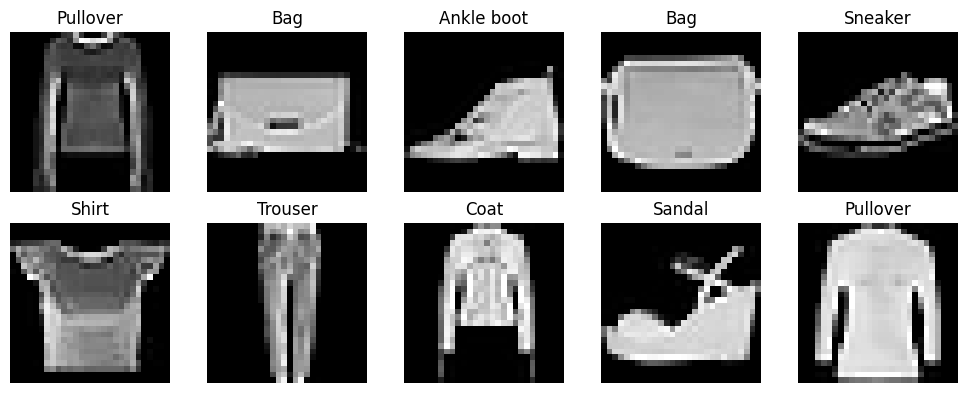

In [9]:
import matplotlib.pyplot as plt

indices = np.random.randint(0, len(x_train), size=(10, ))

rows, cols = 2, 5
fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
for ax, idx in zip(axes.flatten(), indices):
    image = x_train[idx]
    label = y_train[idx]
    ax.imshow(image, cmap='gray')
    ax.set_title(f"{classes[label]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
print(f"Image shape: {x_train[0].shape}")
print(f"Pixel value range: {x_train[0].min()} - {x_train[0].max()}")

Image shape: (28, 28)
Pixel value range: 0 - 255


## Preprocessing the Data

We normalize the pixel values to be in the range [-1, 1]:
- First divide by 255 to get [0, 1], then apply (x - 0.5) / 0.5 to get [-1, 1].


In [14]:
# Normalize to [-1, 1]
x_train_norm = (x_train.astype('float32') / 255.0 - 0.5) / 0.5
x_test_norm = (x_test.astype('float32') / 255.0 - 0.5) / 0.5

print(f"Normalized pixel range: {x_train_norm.min():.1f} to {x_train_norm.max():.1f}")
print(f"Training data shape: {x_train_norm.shape}")
print(f"Test data shape: {x_test_norm.shape}")

Normalized pixel range: -1.0 to 1.0
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


## tf.data.Dataset

We use `tf.data.Dataset` to create batched, shuffled datasets — the TensorFlow equivalent of PyTorch's DataLoader.


In [15]:
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train))
train_dataset = train_dataset.shuffle(buffer_size=10000).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test))
test_dataset = test_dataset.batch(batch_size)

print(f"Number of training batches: {len(train_dataset)}")
print(f"Number of test batches: {len(test_dataset)}")

Number of training batches: 938
Number of test batches: 157


# Developing the Neural Network

We use `tf.keras.Sequential` API to define a simple feedforward neural network.

The architecture matches the PyTorch version:
- **Flatten** layer: 28×28 → 784
- **Dense** layer: 784 → 128, with ReLU activation
- **Dense** (output) layer: 128 → 10 (logits)


In [16]:
simple_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)  # Logits output
])

simple_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## Getting Prediction from the Model

Initially, the model is untrained, so the predictions will be random.


True label: Ankle boot


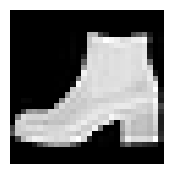

In [17]:
test_image = x_train_norm[122]
test_label = y_train[122]
print(f"True label: {classes[test_label]}")
plt.figure(figsize=(2,2))
plt.imshow(x_train[122], cmap='gray')
plt.axis("off")
plt.show()

In [18]:
test_image.shape

(28, 28)

In [15]:
tf.expand_dims(test_image, 0).shape

TensorShape([1, 28, 28])

In [19]:
# Get prediction from untrained model
predictions = simple_model(tf.expand_dims(test_image, 0))  # add batch dimension
predictions

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[-0.21693043, -0.05740251,  1.7462689 , -0.07343881,  1.1362449 ,
         0.7772967 ,  0.74876386, -0.6298005 ,  1.0014304 , -1.5320082 ]],
      dtype=float32)>

In [20]:
predicted_label = tf.argmax(predictions, axis=1).numpy()[0]
predicted_label

np.int64(2)

In [21]:
classes[predicted_label]  # likely wrong prediction since model is untrained

'Pullover'

## Training the Model

The training process involves the following steps:

1. **Forward Pass:** Input data is passed through the model to obtain predictions.
2. **Loss Calculation:** The difference between the predicted outputs and the actual labels is calculated using a loss function.
3. **Backward Pass:** Gradients are computed using backpropagation.
4. **Parameter Update:** The model's parameters are updated using an optimizer based on the computed gradients.


### Cross Entropy Loss
Cross Entropy Loss is commonly used for multi-class classification problems. It measures the difference between the predicted probability distribution and the true distribution (one-hot encoded labels).
Mathematically, for a single sample, the Cross Entropy Loss is defined as:
$$L = -\sum_{i=1}^{C} y_i \log(p_i)$$
where:
- $C$ is the number of classes,
- $y_i$ represents the true label for class $i$ (1 if the class is the correct class, 0 otherwise),
- $p_i$ is the predicted probability for class $i$.

In [22]:
# Compile the model with loss, optimizer, and metrics
simple_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [23]:
epochs = 10

history = simple_model.fit(
    train_dataset,
    epochs=epochs,
    verbose=1
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7738 - loss: 0.6600
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8311 - loss: 0.4784
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8461 - loss: 0.4378
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8540 - loss: 0.4147
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8596 - loss: 0.3978
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8647 - loss: 0.3846
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8681 - loss: 0.3737
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8716 - loss: 0.3639
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8742 - loss: 0.3553
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8768 - loss: 0.3480


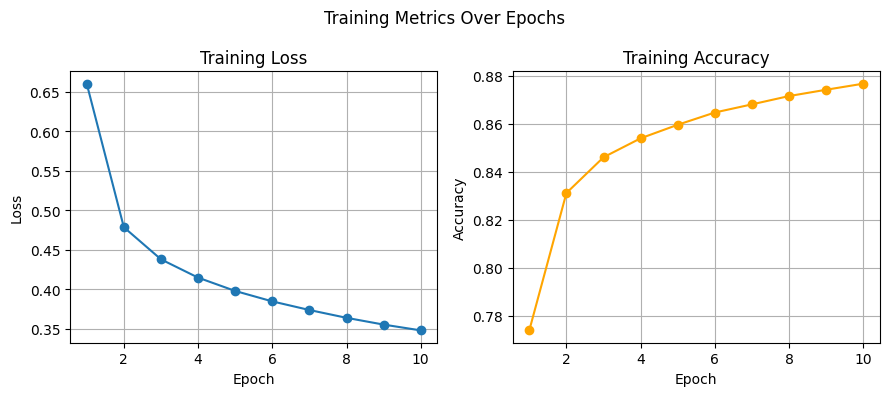

In [24]:
train_losses = history.history['loss']
train_accuracies = history.history['accuracy']

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, marker="o", color="orange")
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()

plt.suptitle("Training Metrics Over Epochs")
plt.tight_layout()
plt.show()

## Evaluating the Model

In [25]:
test_loss, test_accuracy = simple_model.evaluate(test_dataset, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8504
Test Loss: 0.4042


In [26]:
# Get predictions on test set
y_pred_logits = simple_model.predict(x_test_norm, verbose = 0)
y_pred = np.argmax(y_pred_logits, axis=1)

print(f"Actual labels: {y_test[:20].tolist()}")
print(f"Predicted labels: {y_pred[:20].tolist()}")

Actual labels: [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 4, 8, 0]
Predicted labels: [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 2, 8, 0]


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names = classes))

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.74      0.80      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.77      0.75      0.76      1000
       Dress       0.79      0.91      0.84      1000
        Coat       0.81      0.69      0.74      1000
      Sandal       0.94      0.93      0.93      1000
       Shirt       0.59      0.70      0.64      1000
     Sneaker       0.91      0.93      0.92      1000
         Bag       0.95      0.95      0.95      1000
  Ankle boot       0.94      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



<Figure size 800x600 with 0 Axes>

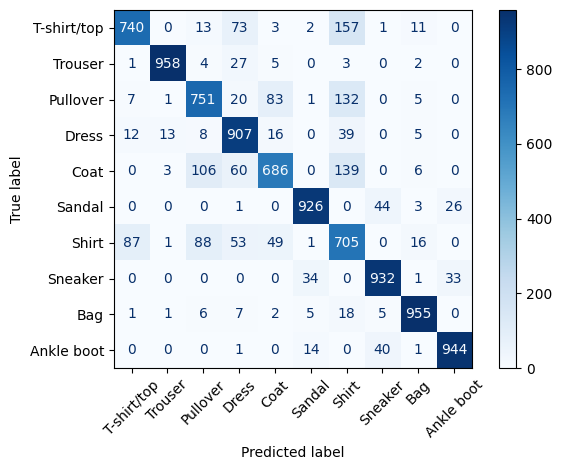

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=classes,
    cmap=plt.cm.Blues,
    xticks_rotation=45
)
plt.tight_layout()
plt.show()

## Inference on New Data

In [36]:
from PIL import Image

test_image = Image.open("ankle_boot.png").convert("RGB")
test_image = np.array(test_image)
test_image.shape

(630, 739, 3)

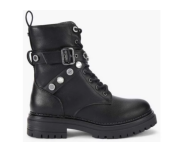

In [37]:
plt.figure(figsize=(2,2))
plt.imshow(test_image, cmap='gray')
plt.axis("off")
plt.show()

Processed image shape: (28, 28)


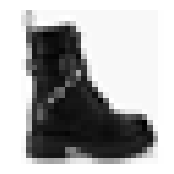

In [38]:
# Preprocess the image for inference
# Convert to grayscale, resize to 28x28, normalize
gray = np.mean(test_image, axis=2)  # convert to grayscale

from PIL import Image as PILImage
gray_pil = PILImage.fromarray(gray.astype('uint8'))
gray_resized = gray_pil.resize((28, 28))
gray_np = np.array(gray_resized).astype('float32')

# Normalize to [-1, 1]
gray_norm = (gray_np / 255.0 - 0.5) / 0.5

print(f"Processed image shape: {gray_norm.shape}")

plt.figure(figsize=(2,2))
plt.imshow(gray_norm, cmap='gray')
plt.axis('off')
plt.show()

In [39]:
# Make prediction
input_tensor = tf.expand_dims(gray_norm, 0)  # add batch dimension
prediction = simple_model(input_tensor)
predicted_class = tf.argmax(prediction, axis=1).numpy()[0]
print(f"Predicted class: {classes[predicted_class]}")

Predicted class: Sneaker


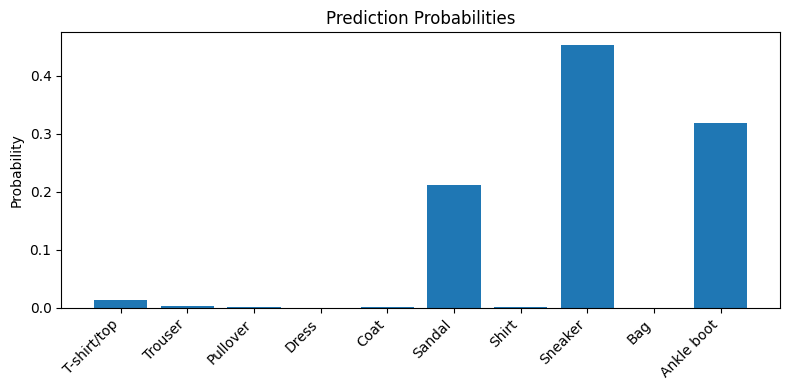

In [40]:
# Show probabilities
probabilities = tf.nn.softmax(prediction).numpy()[0]

plt.figure(figsize=(8, 4))
plt.bar(classes, probabilities)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Probability')
plt.title('Prediction Probabilities')
plt.tight_layout()
plt.show()

In [41]:
simple_model.save('fashion_mnist_model.keras')

In [44]:
# Load the model back
loaded_model = tf.keras.models.load_model('fashion_mnist_model.keras')

loaded_model(input_tensor)  # should give same prediction as simple_model(input_tensor)

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[ 0.6964969, -0.9330229, -2.8402817, -3.623134 , -1.4582846,
         3.4516828, -2.94106  ,  4.213003 , -5.4181986,  3.861742 ]],
      dtype=float32)>